In [1]:
import xarray as xr
import pandas as pd
import numpy as np

In [3]:
pdata = xr.open_dataset("../vae_input_data/tp_mon-sum.nc")

In [5]:
print(pdata)

<xarray.Dataset> Size: 1MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 17, longitude: 17)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 136B 40.0 39.75 39.5 ... 36.5 36.25 36.0
  * longitude        (longitude) float64 136B -123.0 -122.8 ... -119.2 -119.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    tp               (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 18:32:56 2025: CDO monsum ../signal-e...
    frequency:               mon
    CDO:         

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot

# ---------------------------
# LOAD AND PREPARE DATA
# ---------------------------

# Extract precipitation as a flattened 1D array
# pdata is your loaded xarray Dataset
precip = pdata["tp"].values  # shape (time, lat, lon)
precip_flat = precip.flatten()

# Remove invalids
precip_flat = precip_flat[~np.isnan(precip_flat)]

# For transformations
precip_log = np.log1p(precip_flat)  # log(1 + precip)


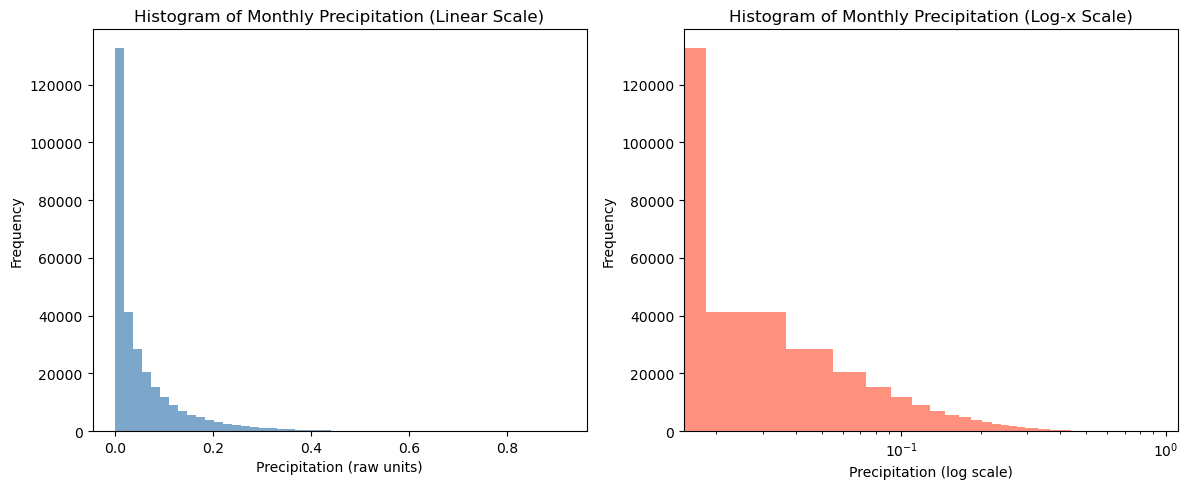

In [7]:

plt.figure(figsize=(12,5))

# Linear histogram
plt.subplot(1,2,1)
plt.hist(precip_flat, bins=50, color='steelblue', alpha=0.7)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("Frequency")
plt.title("Histogram of Monthly Precipitation (Linear Scale)")

# Log-x histogram
plt.subplot(1,2,2)
plt.hist(precip_flat, bins=50, color='tomato', alpha=0.7)
plt.xscale("log")
plt.xlabel("Precipitation (log scale)")
plt.ylabel("Frequency")
plt.title("Histogram of Monthly Precipitation (Log-x Scale)")

plt.tight_layout()
plt.show()


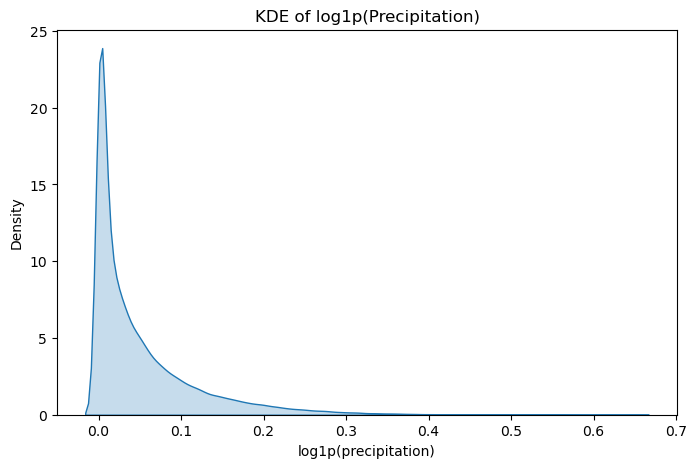

In [8]:
plt.figure(figsize=(8,5))
sns.kdeplot(precip_log, fill=True)
plt.xlabel("log1p(precipitation)")
plt.title("KDE of log1p(Precipitation)")
plt.show()

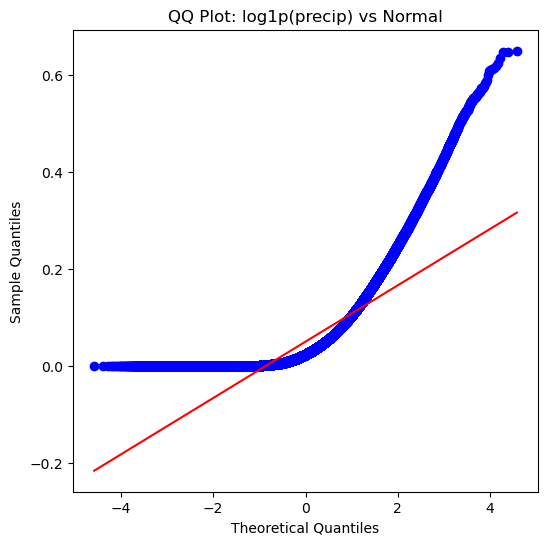

In [9]:
plt.figure(figsize=(6,6))
probplot(precip_log, dist="norm", plot=plt)
plt.title("QQ Plot: log1p(precip) vs Normal")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

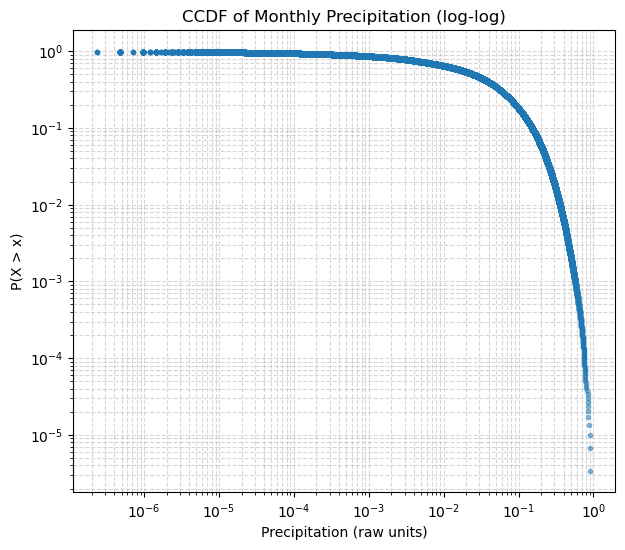

In [10]:
# Sort data
sorted_precip = np.sort(precip_flat)

# CCDF = P(X > x)
ccdf = 1.0 - np.arange(1, len(sorted_precip)+1) / len(sorted_precip)

plt.figure(figsize=(7,6))
plt.loglog(sorted_precip, ccdf, marker='.', linestyle='none', alpha=0.5)
plt.xlabel("Precipitation (raw units)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Monthly Precipitation (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()
